## Model A: Base

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report
import kagglehub
import os
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from PIL import Image

/Users/rashed/Documents/GitHub/Plant_Disease-CNN/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/rashed/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1


In [3]:
# Walk through the dataset directory and print its structure
for root, dirs, files in os.walk(path):
    # Calculate the folder depth for indentation
    level = root.replace(path, "").count(os.sep)
    indent = " " * 2 * level

    print(f"{indent}{os.path.basename(root)}/")

    # Show only the first 3 files in each folder (avoid long output)
    sub_indent = " " * 2 * (level + 1)
    for file in files[:3]:
        print(f"{sub_indent}{file}")

    if len(files) > 3:
        print(f"{sub_indent}... and {len(files) - 3} more files")

1/
  .DS_Store
  Test/
    Test/
      Powdery/
        81f43097df3940d7.jpg
        9f1061a618f3fcc9.jpg
        85ec3f0705065df9.jpg
        ... and 47 more files
      Healthy/
        8ddaac1bd6c8cd0a.jpg
        8eaeaea542a5217b.jpg
        8e858c8397706b7b.jpg
        ... and 47 more files
      Rust/
        95ac93e87a9744d1.jpg
        92f22e07d63e6c8c.jpg
        84c2b48da27b8cf7.jpg
        ... and 47 more files
  Train/
    .DS_Store
    Train/
      .DS_Store
      Powdery/
        a1c0339fb1f470c7.jpg
        8d9173c5b586ae0b.jpg
        98c8333cd39565a7.jpg
        ... and 427 more files
      Healthy/
        9fd72a18e1691527.jpg
        92d85a6ba115dccd.jpg
        8bd27e8d6124a5b3.jpg
        ... and 455 more files
      Rust/
        a8b11628f78a8adf.jpg
        bda896530a3d7855.jpg
        a49bb8b160eadba4.jpg
        ... and 431 more files
  Validation/
    Validation/
      Powdery/
        9cb395dc678b6580.jpg
        8fba25d912583ba6.jpg
        8fc5721dc2f293c1.

In [4]:
# Define the exact paths based on the nested folder structure we discovered
train_dir = os.path.join(path, "Train", "Train")
test_dir = os.path.join(path, "Test", "Test")
valid_dir = os.path.join(path, "Validation", "Validation")

class_names = ["Healthy", "Powdery", "Rust"]

# Function to count images in each class folder
def count_images(base_dir, class_names):
    counts = {}
    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        num_files = len(os.listdir(class_path))
        counts[class_name] = num_files
    return counts

print("Train counts:", count_images(train_dir, class_names))
print("Test counts:", count_images(test_dir, class_names))
print("Validation counts:", count_images(valid_dir, class_names))

Train counts: {'Healthy': 458, 'Powdery': 430, 'Rust': 434}
Test counts: {'Healthy': 50, 'Powdery': 50, 'Rust': 50}
Validation counts: {'Healthy': 20, 'Powdery': 20, 'Rust': 20}


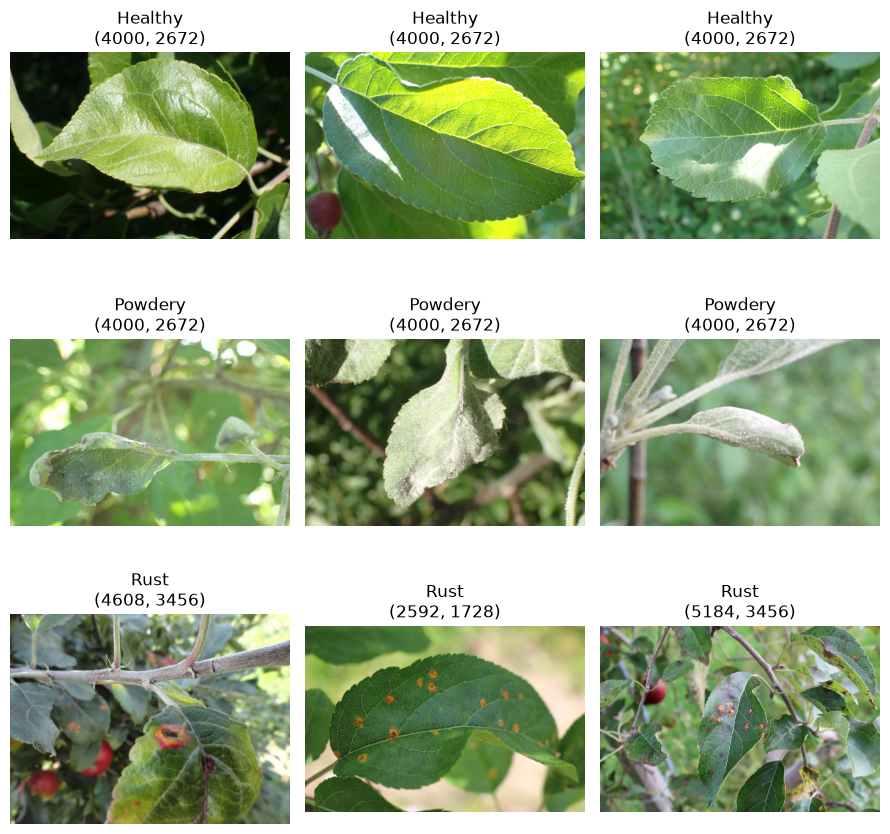

In [5]:


# Create a grid: 3 rows (one per class), 3 columns (sample images)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for row, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    # Get the first 3 image filenames in this class folder
    sample_files = os.listdir(class_path)[:3]

    for col, file_name in enumerate(sample_files):
        img_path = os.path.join(class_path, file_name)
        img = Image.open(img_path)

        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(f"{class_name}\n{img.size}")
        ax.axis("off")

plt.tight_layout()
plt.show()

### Input Resizing

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load the training dataset directly from folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

# Load the validation dataset
valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

# Load the test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.


In [7]:
# NOTE: Speeding up the data pipeline before training
# - cache()    -> keeps images in memory after first read (faster next epoch)
# - shuffle()  -> randomizes order (train set only)
# - prefetch() -> prepares next batch while current one is training

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)   # no shuffle: keep order fixed for evaluation
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)     # no shuffle: keep order fixed for evaluation

In [8]:
def build_cnn(num_classes: int, config: dict) -> keras.Model:
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.RandomFlip("horizontal")(x)

    for filters in config["filters"]:
        x = layers.Conv2D(filters, kernel_size=config["kernel_size"], padding="same", use_bias=not config["batch_norm"])(x)
        if config["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)


    x = layers.Dropout(config["dropout"])(x)

    # ======== NEW ADDED ==== ======================
    for dense in config["dense"]:
        x = layers.Dense(dense, activation="relu")(x)
    # ======== ============== ======================

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=config["name"])

In [9]:
config = {
    "name": "Model_A_Baseline",
    "filters": [32, 64],
    "kernel_size": (3, 3),
    "batch_norm": False,
    "dropout": 0.3,
    "dense": [32]
}

optimizer_a = keras.optimizers.Adam(learning_rate=0.05)
model_a = build_cnn(3, config)
model_a.compile(
    optimizer= optimizer_a,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="model_a.keras",
    monitor="val_loss",
    save_best_only=True
)

In [16]:
history_a = model_a.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 287ms/step - accuracy: 0.3366 - loss: 1.1028 - val_accuracy: 0.3333 - val_loss: 1.1000
Epoch 2/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 273ms/step - accuracy: 0.3253 - loss: 1.1029 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 3/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 274ms/step - accuracy: 0.3124 - loss: 1.1026 - val_accuracy: 0.3333 - val_loss: 1.1001
Epoch 4/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 275ms/step - accuracy: 0.3328 - loss: 1.1021 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 5/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 267ms/step - accuracy: 0.3366 - loss: 1.0997 - val_accuracy: 0.3333 - val_loss: 1.1040


In [17]:
# Find the epoch with the lowest validation loss
val_loss_values = history_a.history["val_loss"]
best_epoch = np.argmin(val_loss_values)

print(f"Best epoch: {best_epoch + 1}")
print(f"Best val_loss: {val_loss_values[best_epoch]:.4f}")
print(f"Best val_accuracy: {history_a.history['val_accuracy'][best_epoch]:.4f}")

Best epoch: 4
Best val_loss: 1.0987
Best val_accuracy: 0.3333


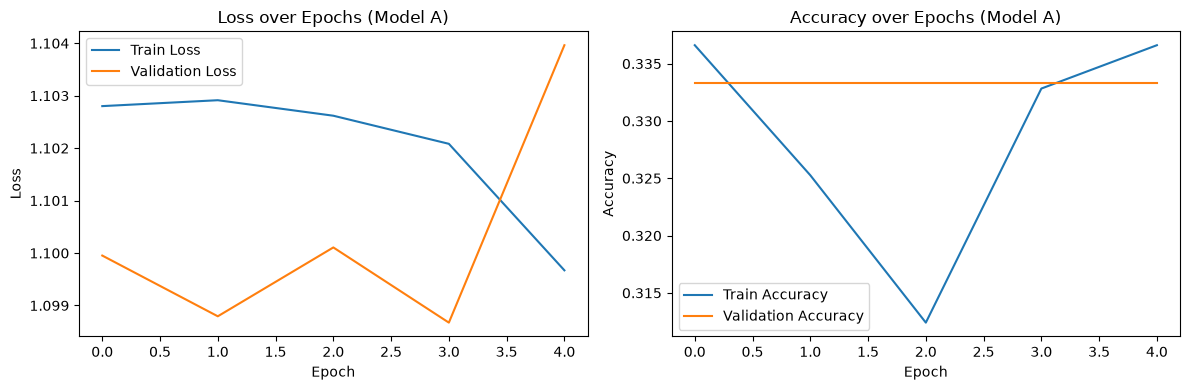

In [18]:

def plot_performance(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot 1: Loss curves
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"Loss over Epochs ({name})")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Plot 2: Accuracy curves
    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_title(f"Accuracy over Epochs ({name})")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_performance(history_a, "Model A")

# Testing

In [19]:
def test_and_report(history):
    y_pred_probs = history.model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_test = np.concatenate([y for x, y in test_ds], axis=0)

    # convert them to class indices first:
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test = np.argmax(y_test, axis=1)

    report = classification_report(y_test, y_pred)
    print(report)

In [20]:
test_and_report(history_a)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step
              precision    recall  f1-score   support

           0       0.33      1.00      0.50        50
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00        50

    accuracy                           0.33       150
   macro avg       0.11      0.33      0.17       150
weighted avg       0.11      0.33      0.17       150



/Users/rashed/Documents/GitHub/Plant_Disease-CNN/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rashed/Documents/GitHub/Plant_Disease-CNN/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rashed/Documents/GitHub/Plant_Disease-CNN/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr